#### Divisive Clustering

It is a type of Clustering algorithm that forms the clusters based on the top-down approach.


#### Algorithm for Divisive Clustering :-------

(a.)  Initially all the data points are under one cluster.

(b.)  Find out the most dissimilar data points from the cluster.

(c.)  Then small clusters are formed from the data.

(d.)  This process will continue unless and until required number of clusters are formed.

(e.)  Or until each data point will become a unique cluster.


#### Step 1: Import all the necessary libraries

In [863]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import train_test_split
from    sklearn.preprocessing       import StandardScaler
from    scipy.cluster.hierarchy     import linkage, dendrogram, fcluster
from    scipy.spatial.distance      import pdist

#### OBSERVATIONS:

1.  pdist ================>  It is used to compute the distance between every pair of the data points in the dataset.

#### Step 2: Load the dataset

In [864]:
#### Load the dataset

df = pd.read_csv("Mall_Customers_dataset.csv")

In [865]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains all the details of the customer along with their "Annual Income" and their "Spending Score".

#### Step 3: Perform the Data Exploration

In [866]:
#### get the first five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [867]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [868]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [869]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [870]:
#### get the columns used in the dataset

print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [871]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [872]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each numerical column used in the dataset.

In [873]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,Genre
count,200
unique,2
top,Female
freq,112


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each categorical column used in the dataset.

#### Step 4: Perform the Data Cleaning and Feature Engineering

In [874]:
#### To rename the column names with their proper names

df.rename(columns={"Genre"                   :   "Gender"             ,
                    "Annual Income (k$)"     :   "Annual_Income"      ,
                    "Spending Score (1-100)" :   "Spending_Score"},
                    inplace=True)

In [875]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  All the column names have been renamed with their proper names.

In [876]:
#### To remove the un necessary column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [877]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The CustomerID column has been removed from the dataset.

In [878]:
#### To convert all the categorical columns of 'Gender' into the numerical values

from  sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

#### using the object for Label Encoder, transform the inputs

df['Gender'] = label.fit_transform(df['Gender'])

In [879]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### OBSERVATIONS:

1.  All the categorical values of Gender column have been converted into their numerical values.

In [880]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [881]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [882]:
#### To get the correlation for all the numerical columns in the dataset

df.corr()

,Gender,Age,Annual_Income,Spending_Score
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual_Income,0.056410,-0.012398,1.000000,0.009903
Spending_Score,-0.058109,-0.327227,0.009903,1.000000


#### OBSERVATIONS:

1.  The above table depicts about the correlation between all the numerical columns used in the dataset.

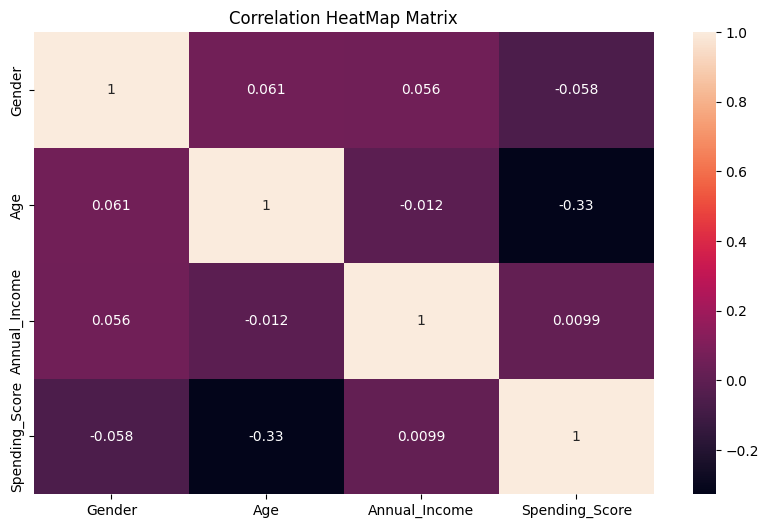

In [883]:
#### To get the graphical representation for the correlation for all the numerical columns in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graphical representation depicts about the numerical correlation for all the column used in the dataset.

2.  The correlation between the 'Gender' and 'Age' is very high.

3.  The correlation between the 'Age' and 'Spending Score' is very low.

#### Step 6: Select Important Features

In [884]:
#### Select all the important features

X = df[['Annual_Income','Spending_Score']]

In [885]:
X

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


#### OBSERVATIONS:

1.  The features that were selected for performing the clustering operation in the dataset is 

    (a.)    Annual_Income

    (b.)    Spending_Score

#### Step 7: Perform the Feature Scaling on the selected features

In [886]:
from sklearn.preprocessing import StandardScaler

##### create an object for StandardScaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

In [887]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

#### OBSERVATIONS:

1.  Feature scaling standardizes all features to zero mean and unit variance.

2.  This prevents one feature from dominating due to larger scale.

####                DIVISIVE CLUSTERING

#### Step 8:  Computing the Distance Matrix

In [888]:
from scipy.spatial.distance import pdist

#### Finding out the euclidean distance

distances = pdist(X_scaled, metric = 'euclidean')

In [889]:
distances

array([1.63050555, 1.28167999, 1.47571302, ..., 2.21418015, 0.54622499,
       2.52340145])

#### OBSERVATIONS:

1.  pdist ===========>  It helps in computing the euclidean distance between every pair of the data points in the dataset.

#### Step 9: Compute the Linkage Matrix

In [890]:
from scipy.cluster.hierarchy    import  dendrogram, linkage

#### Create a linkage matrix

ans = linkage(distances, method = 'ward')

In [891]:
ans

array([[6.50000000e+01, 6.80000000e+01, 0.00000000e+00, 2.00000000e+00],
       [4.80000000e+01, 4.90000000e+01, 0.00000000e+00, 2.00000000e+00],
       [1.56000000e+02, 1.58000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.29000000e+02, 1.31000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.70000000e+02, 1.74000000e+02, 3.81694292e-02, 2.00000000e+00],
       [5.10000000e+01, 5.30000000e+01, 3.81694292e-02, 2.00000000e+00],
       [9.20000000e+01, 9.90000000e+01, 3.81694292e-02, 2.00000000e+00],
       [1.01000000e+02, 1.09000000e+02, 3.81694292e-02, 2.00000000e+00],
       [9.40000000e+01, 9.80000000e+01, 3.81694292e-02, 2.00000000e+00],
       [1.07000000e+02, 1.13000000e+02, 3.81694292e-02, 2.00000000e+00],
       [2.10000000e+01, 2.30000000e+01, 3.81694292e-02, 2.00000000e+00],
       [1.50000000e+02, 1.54000000e+02, 3.88215607e-02, 2.00000000e+00],
       [1.51000000e+02, 1.55000000e+02, 3.88215607e-02, 2.00000000e+00],
       [6.00000000e+01, 6.10000000e+01, 3.88215607e

#### OBSERVATIONS:

1.  The linkage matrix is created to minimize the distances between the variances.

2.  It is used to form the hierarchical clustering.

#### Step 10: Plot the Dendrogram

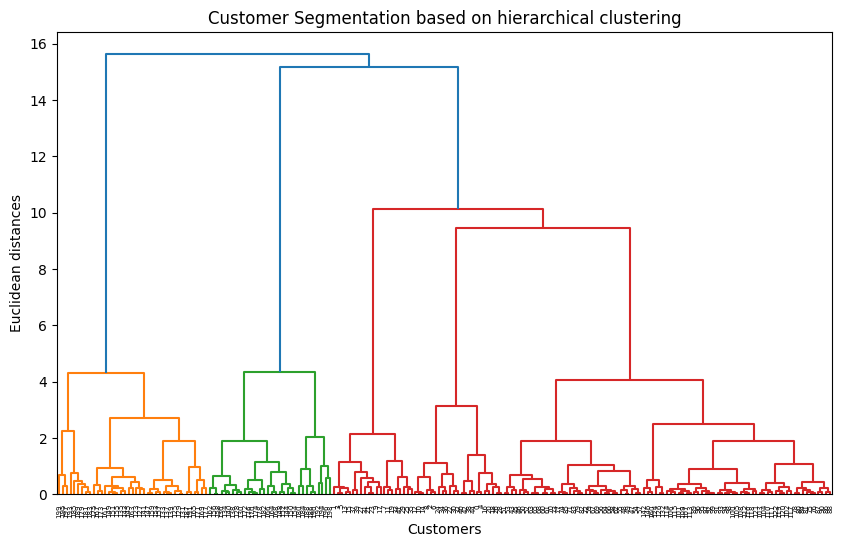

In [892]:
plt.figure(figsize=(10,6))

#### plot the dendrogram
dendrogram(
    ans
)

#### get the title of the graph
plt.title("Customer Segmentation based on hierarchical clustering")

#### get the x-axis of the graph
plt.xlabel("Customers")

#### get the y-axis of the graph
plt.ylabel("Euclidean distances")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  A dendrogram is a tree diagram showing cluster splitting.

####   Interpretation:

    (a.)    Large vertical lines indicate strong separation

    (b.)    We cut the tree where distance is maximum


#### Step 11: Form the clusters from the dendrogram

In [893]:
from scipy.cluster.hierarchy    import fcluster


#### Determine the total number of clusters

clusters = fcluster(ans,5,criterion = 'maxclust')

In [894]:
print("Total clusters to be formed is:", clusters)

Total clusters to be formed is: [4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 5 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 1 5 1 5 1 2 1 2 1 5 1 2 1 2 1 2 1 2 1 5 1 2 1 5 1
 2 1 2 1 2 1 2 1 2 1 2 1 5 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


#### OBSERVATIONS:

1.  From the above dendrogram, only five (5) clusters are formed.

2.  fcluster =============>  It is used to form the clusters from the dendrogram with the help of the follwoing parameters :----------

    (a.)    ans =============>   Input is the linkage matrix which is used to create the hierarchical clustering.

    (b.)    n = 5 ===========>   Total 5 clusters are formed.

    (c.)    criterion = 'maxclust' =======>   maximum clusters are to be formed.

#### Step 12: Add the clusters to the dataset

In [895]:
df['Clusters'] = clusters

In [896]:
df.head()

,Gender,Age,Annual_Income,Spending_Score,Clusters
0,1,19,15,39,4
1,1,21,15,81,3
2,0,20,16,6,4
3,0,23,16,77,3
4,0,31,17,40,4


#### OBSERVATIONS:

1.  All the clusters have been added to the dataset.

#### Step 13: Visualize the Clusters

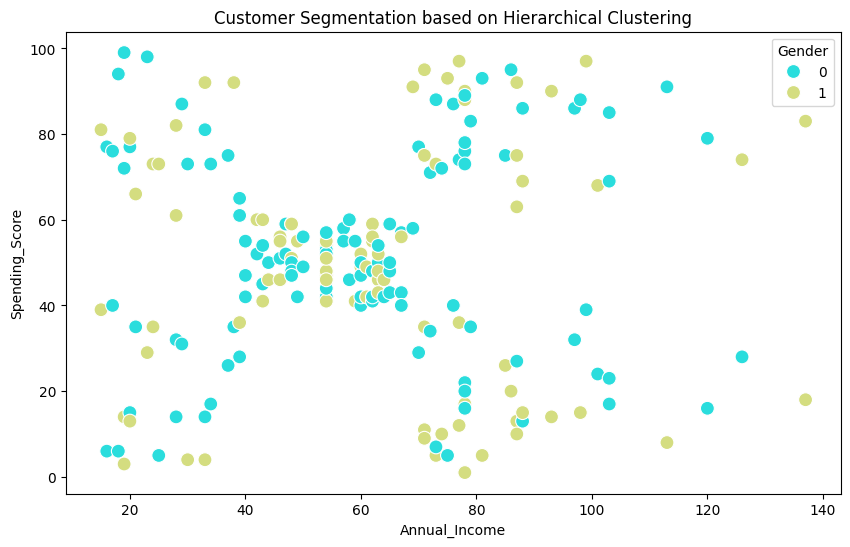

In [897]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x           =           df['Annual_Income']         ,
    y           =           df['Spending_Score']        ,
    hue         =           df['Gender']                ,
    palette     =           'rainbow'                   ,
    s           =               100
)

#### give the title of the graph
plt.title("Customer Segmentation based on Hierarchical Clustering")

#### display the graph
plt.show()

#### OBSERVATIONS:


1. Customer Interpretation

| Cluster                     | Meaning           |
| --------------------------- | ----------------- |
| High Income + High Spending | Premium Customers |
| Low Income + Low Spending   | Budget Customers  |
| High Income + Low Spending  | Careful Customers |

2.  Female Customers are spending more than the Male Customers.


#### (a.)  Analyze Cluster Centers

In [898]:
df.groupby("Gender")[["Annual_Income","Spending_Score"]].mean()

,Annual_Income,Spending_Score
Gender,,
0,59.250000,51.526786
1,62.227273,48.511364


#### OBSERVATIONS:

1.  From the above chart we can see that

    (a.)    The Annual Income of the Male Customers is much higher than the female customers.

    (b.)    The Spending score of the female customers is much higher than the male customers.